# 1. - Cкачиваем обученные модели и репозиторий

In [ ]:
%cd /content
!rm -rf HW-2_env
!git clone https://github.com/TebelevGt/HW-2_env.git
%cd HW-2_env
# Переключаемся на нужную ветку ПЕРЕД переходом в подпапку rl-shortest-path-agent
!git checkout HW_3_hybrid_rl
%cd rl-shortest-path-agent

# 2. - Логика импортов

In [ ]:
#!pip uninstall -y vllm -q
#!pip install vllm==0.6.3.post1 -q
#!pip install transformers==4.46.1 -q

In [ ]:
import numpy as np
from vllm import LLM, SamplingParams
from envs.base_classes import Data
from envs import (
    get_shortest_path_dataset,
    correctness_reward_func,
    reasoning_length_reward_func,
    format_reward_func,
    evaluate_agent,
    PathEnv,
    ShortestPathDataset,
    PathVerifier
)

# 3. - Ломаем pass@128

In [ ]:
def create_hard_subsets_vllm(model_name: str, train_ds, val_ds, verifier, n=128):
    print(f"🚀 Загрузка {model_name} через vLLM...")

    # Добавляем enforce_eager=True — это спасает T4 от падений при компиляции графов
    llm = LLM(
        model=model_name,
        tensor_parallel_size=1,
        max_model_len=2048, # 💡 Снизил с 4096 до 2048 (см. причину ниже)
        gpu_memory_utilization=0.9,
        enforce_eager=True,  # 💡 Отключает CUDA-графы, работает стабильнее
        dtype="half"
    )
    tokenizer = llm.get_tokenizer()

    sampling_params = SamplingParams(
        n=n,
        temperature=0.7,
        max_tokens=512,
    )
    def process_dataset(dataset, split_name):
        print(f"\n⚙️ Обработка {split_name} ({len(dataset)} задач)...")

        # 1. Формируем промпты в формате чата
        prompts = [tokenizer.apply_chat_template(ex["prompt"], tokenize=False, add_generation_prompt=True) for ex in dataset]

        # 2. Массовая генерация (vLLM сделает это невероятно быстро)
        results = llm.generate(prompts, sampling_params)

        # 3. Проверка ответов
        hard_indices = []
        for i, (item, output) in enumerate(zip(dataset, results)):
            # Восстанавливаем объект Data для твоего верификатора
            data_obj = Data(question="", answer="", difficulty=0, metadata={
                "matrix": np.array(item["matrix"]), "start": item["start"], "end": item["end"]
            })

            # Проверяем все 128 ответов (output.outputs содержит их все)
            is_solved = any(verifier.verify(data_obj, gen.text) for gen in output.outputs)

            # Если ни один из 128 ответов не подошел — берем в Hard
            if not is_solved:
                hard_indices.append(i)

        hard_ds = dataset.select(hard_indices)
        print(f"🔥 Итог {split_name}: {len(hard_ds)} Hard-задач из {len(dataset)}")
        return hard_ds

    # Прогоняем обе выборки
    hard_train = process_dataset(train_ds, "Train")
    hard_val = process_dataset(val_ds, "Val")

    return hard_train, hard_val

In [ ]:
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

# Загружаем исходные данные
full_train = get_shortest_path_dataset("data/train_v1.pkl")
subset_train = full_train.shuffle(seed=42).select(range(1000))
full_val = get_shortest_path_dataset("data/test_hard.pkl") # Лучше брать сразу hard/medium для валидации

verifier = PathVerifier()

# Получаем отфильтрованные датасеты
hard_train, hard_val = create_hard_subsets_vllm(MODEL_ID, subset_train, full_val, verifier, n=128)

In [ ]:
def convert_hf_to_pkl(hf_dataset, save_path):
    data_objects = []

    for item in hf_dataset:
        # Достаем текст вопроса. В hf_dataset промпт лежит в виде списка словарей:
        # [{"role": "system", ...}, {"role": "user", "content": "вопрос..."}]
        question_text = item["prompt"][1]["content"]

        # Восстанавливаем метаданные, превращая матрицу обратно в numpy array
        metadata = {
            "matrix": np.array(item["matrix"]),
            "start": item["start"],
            "end": item["end"],
            "optimal_cost": item["optimal_cost"]
        }

        # Собираем твой объект Data
        data_obj = Data(
            question=question_text,
            answer=item["answer"],
            difficulty=0,  # Этот параметр мы потеряли при конвертации в HF, но для оценки он уже не нужен
            metadata=metadata
        )
        data_objects.append(data_obj)

    # Оборачиваем список в твой класс и сохраняем через его встроенный метод
    sp_dataset = ShortestPathDataset(data_objects)
    sp_dataset.save(save_path)

# Вызываем функцию напрямую для твоих существующих переменных
print("Упаковываем train...")
convert_hf_to_pkl(hard_train, "data/hard_train_128.pkl")

print("Упаковываем val...")
convert_hf_to_pkl(hard_val, "data/hard_val_128.pkl")

# Доказательства, что я честно нагенерил hard train
ячейки почистил, но картинку сохранил

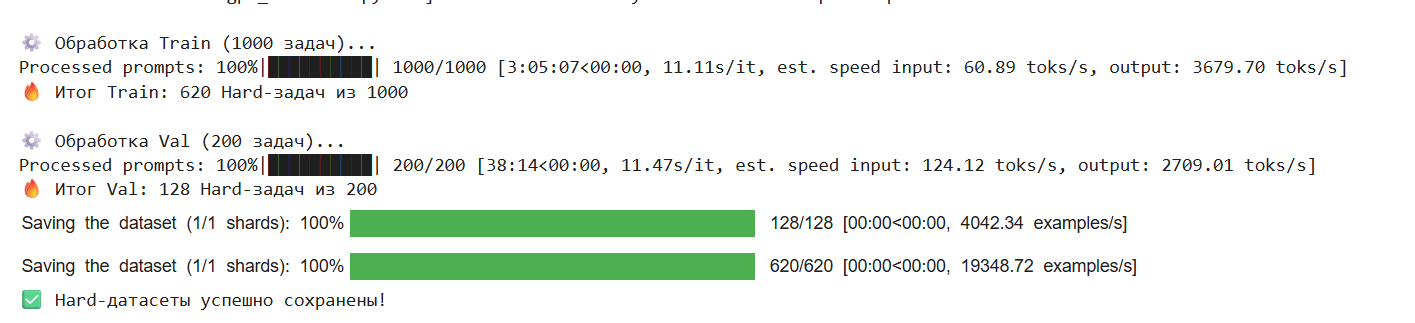